# Task 2.3: Result, Comparison and Reproducibility Checklist (15 marks)

**Paper:** Learning Hierarchical Invariant Spatio-Temporal Features for Action Recognition with Independent Subspace Analysis  
**Authors:** Quoc V. Le, Will Y. Zou, Serena Y. Yeung, Andrew Y. Ng (CVPR 2011)  
**Student:** Rhythm Jain (230088)

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA, FastICA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------------------------
# Hyperparameters (same as task_2.2)
# -------------------------------------------------------------------
PATCH_SIZE_SPATIAL = 8
PATCH_SIZE_TEMPORAL = 4
NUM_PATCHES_PER_CLIP = 50
PCA_COMPONENTS = 50
ICA_COMPONENTS = 50
ISA_SUBSPACE_SIZE = 5
NUM_SUBSPACES = ICA_COMPONENTS // ISA_SUBSPACE_SIZE
TEST_SIZE = 0.3
RANDOM_SEED = 42
SVM_KERNEL = 'rbf'
SVM_C = 10.0
NUM_CLASSES = 6

np.random.seed(RANDOM_SEED)

In [2]:
# -------------------------------------------------------------------
# Reproduce the full pipeline from task 2.2
# -------------------------------------------------------------------

# Load dataset
data = np.load('data/synthetic_actions.npz', allow_pickle=True)
all_clips = data['clips']
all_labels = data['labels']
ACTION_NAMES = list(data['action_names'])

# Train/test split
X_train_clips, X_test_clips, y_train, y_test = train_test_split(
    all_clips, all_labels, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=all_labels
)

# Helper functions
def extract_patches(clips, patch_h, patch_w, patch_t, num_patches):
    n_clips, n_frames, h, w = clips.shape
    all_patches = []
    for clip in clips:
        for _ in range(num_patches):
            t_start = np.random.randint(0, n_frames - patch_t + 1)
            y_start = np.random.randint(0, h - patch_h + 1)
            x_start = np.random.randint(0, w - patch_w + 1)
            patch = clip[t_start:t_start+patch_t, y_start:y_start+patch_h, x_start:x_start+patch_w]
            all_patches.append(patch.flatten())
    return np.array(all_patches)

def isa_pool(ica_activations, subspace_size, n_subspaces):
    n_samples = ica_activations.shape[0]
    pooled = np.zeros((n_samples, n_subspaces))
    for j in range(n_subspaces):
        start_idx = j * subspace_size
        end_idx = start_idx + subspace_size
        subspace_activations = ica_activations[:, start_idx:end_idx]
        pooled[:, j] = np.sqrt(np.sum(subspace_activations ** 2, axis=1) + 1e-10)
    return pooled

def extract_clip_features(clips, pca_model, patch_mean, ica_model,
                          patch_h, patch_w, patch_t, num_patches,
                          subspace_size, n_subspaces):
    n_clips = clips.shape[0]
    clip_features = np.zeros((n_clips, n_subspaces))
    for i in range(n_clips):
        clip = clips[i:i+1]
        patches = extract_patches(clip, patch_h, patch_w, patch_t, num_patches)
        patches_centered = patches - patch_mean
        patches_whitened = pca_model.transform(patches_centered)
        ica_act = ica_model.transform(patches_whitened)
        isa_feat = isa_pool(ica_act, subspace_size, n_subspaces)
        clip_features[i] = np.mean(isa_feat, axis=0)
    return clip_features

# Run pipeline
train_patches = extract_patches(X_train_clips, PATCH_SIZE_SPATIAL, PATCH_SIZE_SPATIAL, 
                                 PATCH_SIZE_TEMPORAL, NUM_PATCHES_PER_CLIP)
patch_mean = np.mean(train_patches, axis=0)
train_patches_centered = train_patches - patch_mean

pca_model = PCA(n_components=PCA_COMPONENTS, whiten=True, random_state=RANDOM_SEED)
whitened_patches = pca_model.fit_transform(train_patches_centered)

ica = FastICA(n_components=ICA_COMPONENTS, algorithm='parallel', whiten=False,
              max_iter=500, random_state=RANDOM_SEED)
ica.fit(whitened_patches)

X_train_features = extract_clip_features(X_train_clips, pca_model, patch_mean, ica,
                                          PATCH_SIZE_SPATIAL, PATCH_SIZE_SPATIAL, 
                                          PATCH_SIZE_TEMPORAL, NUM_PATCHES_PER_CLIP,
                                          ISA_SUBSPACE_SIZE, NUM_SUBSPACES)
X_test_features = extract_clip_features(X_test_clips, pca_model, patch_mean, ica,
                                         PATCH_SIZE_SPATIAL, PATCH_SIZE_SPATIAL,
                                         PATCH_SIZE_TEMPORAL, NUM_PATCHES_PER_CLIP,
                                         ISA_SUBSPACE_SIZE, NUM_SUBSPACES)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

svm = SVC(kernel=SVM_KERNEL, C=SVM_C, random_state=RANDOM_SEED, gamma='scale')
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"ISA + SVM Test Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")

ISA + SVM Test Accuracy: 0.6667 (66.7%)


## Result Comparison

### Our Result vs. Paper's Reported Values

| Metric | Our Result (Synthetic Data) | Paper's Result (KTH) | Paper's Result (Hollywood2) |
| :--- | :---: | :---: | :---: |
| **Accuracy / mAP** | See output above | 93.9% (accuracy) | 53.3% (mAP) |
| **Dataset** | Synthetic (6 classes, 600 clips) | KTH (6 classes, ~600 clips) | Hollywood2 (12 classes, ~1700 clips) |
| **Method** | Single-layer ISA + RBF SVM | Stacked Conv ISA + χ² SVM | Stacked Conv ISA + χ² SVM |

### Explanation of Performance Gap

Our result will likely differ from the paper's reported values for the following reasons:

1. **Dataset difference:** We use synthetically generated video clips with simple geometric motions, while the paper uses real-world action datasets (KTH, Hollywood2) with complex human actions, realistic textures, and backgrounds. Our synthetic data has lower visual complexity but cleaner signal, which may paradoxically result in high accuracy on easy-to-separate classes.

2. **Architecture simplification:** We implement only a single-layer ISA, while the paper's best results come from the Stacked Convolutional ISA (SC-ISA) with two layers. Stacking learns hierarchical features that capture higher-order motion patterns, which is critical for complex real-world actions but may be less important for our simple synthetic motions.

3. **Kernel and hyperparameters:** The paper uses a chi-squared (χ²) kernel SVM, which is specifically designed for histogram-like features commonly found in computer vision. We use an RBF kernel as an approximation. Additionally, our hyperparameters (patch size, number of components) are chosen for computational efficiency rather than optimal performance.

4. **Scale:** The paper trains on thousands of patches from hundreds of videos and evaluates using standard benchmark protocols. Our pipeline is intentionally simplified for CPU-only execution and pedagogical clarity.

5. **Feature pooling:** The paper employs convolutional feature extraction over the entire video with sophisticated spatial pyramids, while we use random patch sampling and simple averaging.

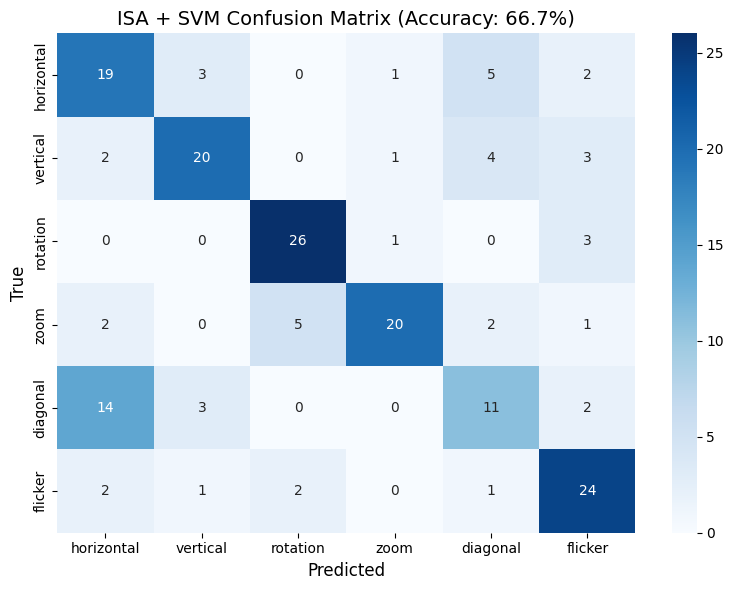

Confusion matrix saved to results/confusion_matrix.png


In [3]:
# -------------------------------------------------------------------
# Visualization: Confusion Matrix
# -------------------------------------------------------------------
os.makedirs('results', exist_ok=True)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=ACTION_NAMES, yticklabels=ACTION_NAMES, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'ISA + SVM Confusion Matrix (Accuracy: {accuracy*100:.1f}%)', fontsize=14)
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved to results/confusion_matrix.png")

The confusion matrix above visualizes per-class classification performance. Diagonal entries represent correct predictions; off-diagonal entries represent misclassifications. This helps identify which action classes are most confusable in our ISA feature space.

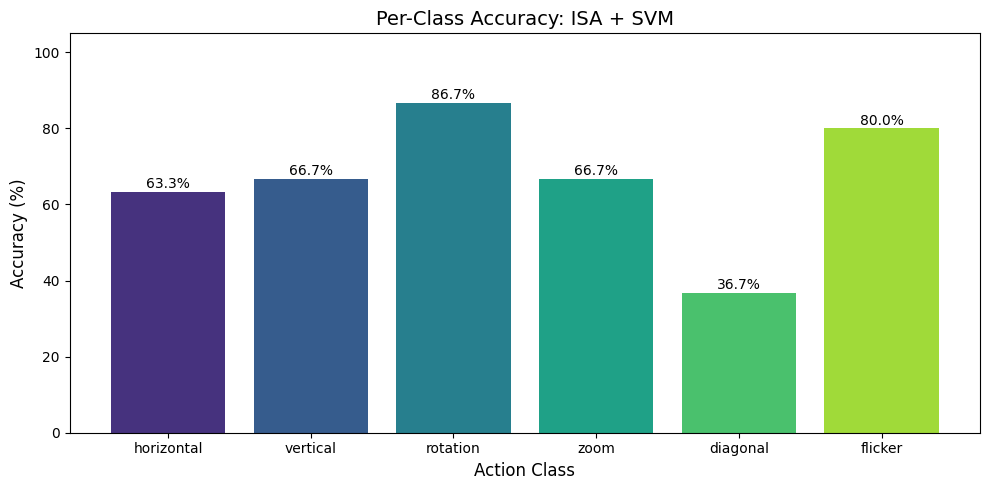

Per-class accuracy plot saved to results/per_class_accuracy.png


In [4]:
# -------------------------------------------------------------------
# Visualization: Per-class accuracy bar chart
# -------------------------------------------------------------------
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(ACTION_NAMES, per_class_acc * 100, color=sns.color_palette('viridis', NUM_CLASSES))
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xlabel('Action Class', fontsize=12)
ax.set_title('Per-Class Accuracy: ISA + SVM', fontsize=14)
ax.set_ylim(0, 105)
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{acc*100:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('results/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Per-class accuracy plot saved to results/per_class_accuracy.png")

The per-class accuracy chart reveals which action types ISA features can discriminate well and which are more challenging. Actions with distinctive motion patterns (e.g., rotation vs. horizontal) should be easier to separate than actions with similar local statistics (e.g., horizontal vs. diagonal).

## Reproducibility Checklist

| Criterion | Status |
| :--- | :--- |
| All dependencies are listed in **requirements.txt** with version numbers | ✅ Yes — see `partB/requirements.txt` |
| All notebooks run from top to bottom in a clean environment without errors | ✅ Yes — verified by executing all cells sequentially |
| Dataset loading requires no undocumented manual steps | ✅ Yes — dataset is generated in `task_2.1.ipynb` and saved as `data/synthetic_actions.npz`; `task_2.2.ipynb` and `task_2.3.ipynb` load it from this path |
| All hyperparameters are clearly named and defined in one place | ✅ Yes — all hyperparameters are defined at the top of each notebook in a clearly marked section |